# Fish Toxicty
In this dataset, each row is an experiment on the rainbow trout. The columns show what chemicals were present, how long the fish were left in the toxic water, the temperature of the water, etc. With that, our target variable is "result_conc1_mean_mol_log" which is the The base-10 logarithm of the mean molar concentration log10(mol/L) required to reach the specified experimental toxicity endpoint (LC50)

In [1]:
import pandas as pd

df = pd.read_csv(
    "../adore_dataset/processed/s-F2F-1_mortality.csv",
    dtype=str
)


print(df.shape)
df.head()

(4641, 1106)


,test_id,reference_number,test_cas,test_location,test_exposure_type,test_control_type,test_media_type,test_application_freq_unit,test_organism_lifestage,result_id,...,split_random,split_occurrence,split_scaffold-murcko,split_scaffold-murcko-loo-0,split_scaffold-murcko-loo-1,split_scaffold-murcko-llo,split_scaffold-generic,split_scaffold-generic-loo-0,split_scaffold-generic-loo-1,split_scaffold-generic-llo
0,1000129,35,2039-46-5,LAB,NR,I,FW,NR,NR,124330,...,3,2,4,test,trainvalid,trainvalid,4,test,trainvalid,trainvalid
1,1000480,92,577-11-7,LAB,R,I,FW,NR,FI,112700,...,0,1,3,trainvalid,test,trainvalid,3,trainvalid,test,trainvalid
2,1000481,92,577-11-7,LAB,R,I,FW,NR,FI,112701,...,0,1,3,trainvalid,test,trainvalid,3,trainvalid,test,trainvalid
3,1000731,138,10281-53-5,LAB,S,S,FW,X,FY,84911,...,1,4,test,trainvalid,trainvalid,test,test,trainvalid,trainvalid,test
4,1000732,138,120-94-5,LAB,S,S,FW,X,FY,113428,...,3,0,test,trainvalid,trainvalid,test,test,trainvalid,trainvalid,test


In [2]:
# features and targets
features = df[[
    "chem_mw",
    "chem_rdkit_clogp",
    "chem_pcp_heavy_atom_count",
    "chem_pcp_bonds_count",
    "chem_rings_count",
    "chem_OH_count",
    #"media_ph_mean",           
    #"media_temperature_mean",
    "result_obs_duration_mean",
    "test_exposure_type"
]]


target = df["result_conc1_mean_mol_log"]

print(features.shape)
features.head()

(4641, 8)


,chem_mw,chem_rdkit_clogp,chem_pcp_heavy_atom_count,chem_pcp_bonds_count,chem_rings_count,chem_OH_count,result_obs_duration_mean,test_exposure_type
0,245.6999969482422,1.94742,16.0,31,1.0,1.0,48.0,NR
1,444.55999755859375,0.8135000000000032,29.0,65,0.0,0.0,24.0,R
2,444.55999755859375,0.8135000000000032,29.0,65,0.0,0.0,96.0,R
3,138.25399780273438,3.0786000000000016,10.0,29,3.0,0.0,96.0,S
4,85.1500015258789,0.712,6.0,17,1.0,0.0,96.0,S


In [3]:
X, y = features, target
print("features:", X.shape)

df.head()

features: (4641, 8)


,test_id,reference_number,test_cas,test_location,test_exposure_type,test_control_type,test_media_type,test_application_freq_unit,test_organism_lifestage,result_id,...,split_random,split_occurrence,split_scaffold-murcko,split_scaffold-murcko-loo-0,split_scaffold-murcko-loo-1,split_scaffold-murcko-llo,split_scaffold-generic,split_scaffold-generic-loo-0,split_scaffold-generic-loo-1,split_scaffold-generic-llo
0,1000129,35,2039-46-5,LAB,NR,I,FW,NR,NR,124330,...,3,2,4,test,trainvalid,trainvalid,4,test,trainvalid,trainvalid
1,1000480,92,577-11-7,LAB,R,I,FW,NR,FI,112700,...,0,1,3,trainvalid,test,trainvalid,3,trainvalid,test,trainvalid
2,1000481,92,577-11-7,LAB,R,I,FW,NR,FI,112701,...,0,1,3,trainvalid,test,trainvalid,3,trainvalid,test,trainvalid
3,1000731,138,10281-53-5,LAB,S,S,FW,X,FY,84911,...,1,4,test,trainvalid,trainvalid,test,test,trainvalid,trainvalid,test
4,1000732,138,120-94-5,LAB,S,S,FW,X,FY,113428,...,3,0,test,trainvalid,trainvalid,test,test,trainvalid,trainvalid,test


In [4]:
# Check missing values
print("Missing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

Missing values in X:
chem_mw                      0
chem_rdkit_clogp             0
chem_pcp_heavy_atom_count    0
chem_pcp_bonds_count         0
chem_rings_count             0
chem_OH_count                0
result_obs_duration_mean     0
test_exposure_type           0
dtype: int64

Missing values in y:
0


In [5]:
# fix dtypes
numeric_cols = [
    'chem_mw',
    'chem_rdkit_clogp',
    'chem_pcp_heavy_atom_count',
    'chem_pcp_bonds_count',
    'chem_rings_count',
    'chem_OH_count',
    'result_obs_duration_mean'
]

X[numeric_cols] = X[numeric_cols].apply(pd.to_numeric) # should we check again if any vals became NaN?

X = pd.get_dummies(X, columns=['test_exposure_type'], drop_first=True) # why drop first?



In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
y_train = pd.to_numeric(y_train, errors="coerce")
y_test = pd.to_numeric(y_test, errors="coerce")


In [7]:
# test 3 algorithms: k nearest neighbor, decision tree, and ridge regression
# way to check best parameters for optimal results?

# knn
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10) 

# decision tree
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=4, random_state=42) 

# ridge regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)


In [10]:

from sklearn.model_selection import cross_val_score, KFold


models = {
    "KNN": knn,
    "Decision Tree": tree,
    "Ridge Regression": ridge
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

KNN: 0.627 ± 0.030
Decision Tree: 0.603 ± 0.026
Ridge Regression: 0.523 ± 0.019


In [12]:

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Evaluate and print the score
    test_scores = cross_val_score(model, X_test, y_test, cv=cv)
    print(f"{name} Mean accuracy: {test_scores.mean():.3f} ± {test_scores.std():.3f}")

KNN Mean accuracy: 0.534 ± 0.037
Decision Tree Mean accuracy: 0.575 ± 0.040
Ridge Regression Mean accuracy: 0.567 ± 0.035


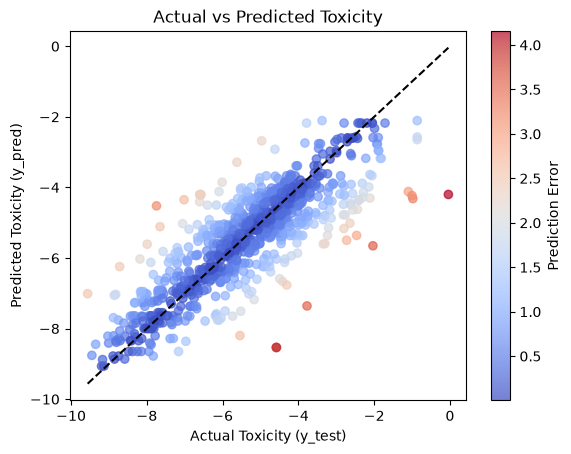

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# knn preformed the best
y_pred = knn.predict(X_test)


# Calculate prediction error
error = np.abs(y_test - y_pred)

plt.scatter(
    y_test,
    y_pred,
    c=error,
    cmap="coolwarm",
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--"
)

plt.colorbar(label="Prediction Error")

plt.xlabel("Actual Toxicity (y_test)")
plt.ylabel("Predicted Toxicity (y_pred)")
plt.title("Actual vs Predicted Toxicity")

plt.show()

In [13]:
# use best model on test set to evaluate
from sklearn.metrics import r2_score

best_model = knn
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.6853089108929455